In [18]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import KFold, cross_val_score

In [2]:
df=pd.read_csv("diamonds.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=53940, step=1)
All columns are
0 carat
1 cut
2 color
3 clarity
4 depth
5 table
6 x
7 y
8 z
9 price


In [3]:
df.shape

(53940, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   x        53940 non-null  float64
 7   y        53940 non-null  float64
 8   z        53940 non-null  float64
 9   price    53940 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [5]:
for i in df.select_dtypes(include=['object', 'string']):
    counts = df[i].value_counts()
    print(counts)

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64


In [6]:
# Features and target seperation

X = df.drop(['price'],axis = 1)
y = df['price']

In [7]:
# Training a general random forest
categorical_cols = X.select_dtypes(include='object').columns


preprocessor = ColumnTransformer([
    ('cat',
     OneHotEncoder(drop='first', handle_unknown='ignore'),
     categorical_cols)
], remainder='passthrough')


rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])


In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


rf_pipe.fit(X_train, y_train)


print("Train R²:", rf_pipe.score(X_train, y_train))
print("Test R²:", rf_pipe.score(X_test, y_test))


Train R²: 0.9967477572222939
Test R²: 0.9745444374938348


In [9]:
# Cross Validation

cv_scores = cross_val_score(
    rf_pipe,
    X,
    y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("\nCV Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())


CV Scores: [ 0.38851889  0.29335203  0.64245669 -0.54392954 -0.06378749]
Mean CV R²: 0.14332211691881422


In [14]:
print('''This much difference in the scores is an big anomaly 
it may be beacuse the dataset is ordered 
Let's Verify it
''')

This much difference in the scores is an big anomaly 
it may be beacuse the dataset is ordered 
Let's Verify it



<Axes: >

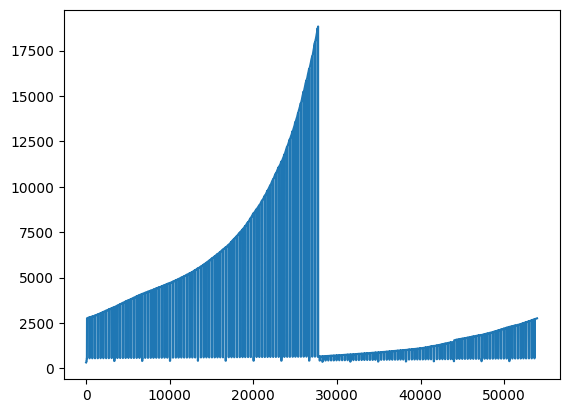

In [15]:
df["price"].plot()

In [16]:
print("Just as i suspected the dataset is not shuffled")

Just as i suspected the dataset is not shuffled


In [19]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf_pipe,
    X,
    y,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

print(cv_scores)
print(cv_scores.mean())

[0.97458992 0.97706186 0.97069209 0.97682962 0.97673142]
0.9751809814771064


In [22]:
# We can also shuffle the whole dataset also
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

<Axes: >

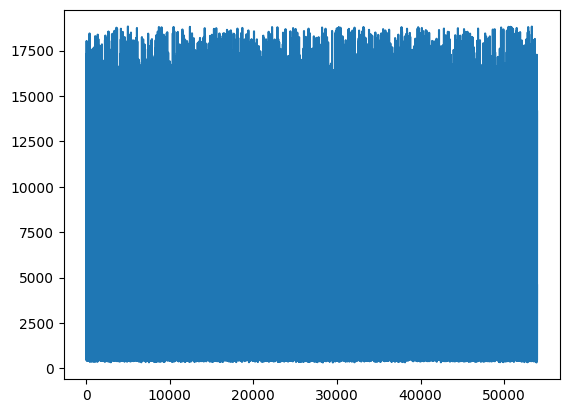

In [23]:
df["price"].plot()

In [24]:

X = df.drop(['price'],axis = 1)
y = df['price']

categorical_cols = X.select_dtypes(include='object').columns


preprocessor = ColumnTransformer([
    ('cat',
     OneHotEncoder(drop='first', handle_unknown='ignore'),
     categorical_cols)
], remainder='passthrough')


rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


rf_pipe.fit(X_train, y_train)


print("Train R²:", rf_pipe.score(X_train, y_train))
print("Test R²:", rf_pipe.score(X_test, y_test))

# Cross Validation

cv_scores = cross_val_score(
    rf_pipe,
    X,
    y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("\nCV Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

Train R²: 0.9966371776386366
Test R²: 0.9742608204051325

CV Scores: [0.97749296 0.97479128 0.9768274  0.97573502 0.97497897]
Mean CV R²: 0.9759651265855753
